In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import urllib.request

In [2]:
def load_rgb_from_url(url):
    data = urllib.request.urlopen(url).read()
    arr = np.frombuffer(data, dtype=np.uint8)
    bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

In [3]:
def pad_reflect(img, pad_h, pad_w):
    if img.ndim == 2:
        return np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    return np.pad(img, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode='reflect')

In [4]:
def apply_filter_numpy(img, kernel):
    img = img.astype(np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = pad_reflect(img, ph, pw)
    out = np.zeros_like(img, dtype=np.float64)

    if img.ndim == 2:
        h, w = img.shape
        for y in range(h):
            for x in range(w):
                region = padded[y:y + kh, x:x + kw]
                out[y, x] = np.sum(region * kernel)
    else:
        h, w, c = img.shape
        for y in range(h):
            for x in range(w):
                region = padded[y:y + kh, x:x + kw, :]
                for ch in range(c):
                    out[y, x, ch] = np.sum(region[:, :, ch] * kernel)

    return np.clip(out, 0, 255).astype(np.uint8)

In [5]:
def median_blur_numpy(img, ksize):
    ph = ksize // 2
    pw = ksize // 2
    padded = pad_reflect(img, ph, pw)
    out = np.zeros_like(img)

    if img.ndim == 2:
        h, w = img.shape
        for y in range(h):
            for x in range(w):
                region = padded[y:y + ksize, x:x + ksize]
                out[y, x] = np.median(region)
    else:
        h, w, c = img.shape
        for y in range(h):
            for x in range(w):
                region = padded[y:y + ksize, x:x + ksize, :]
                for ch in range(c):
                    out[y, x, ch] = np.median(region[:, :, ch])

    return out.astype(np.uint8)

In [6]:
def gaussian_kernel(size, sigma):
    ax = np.arange(-(size // 2), size // 2 + 1, dtype=np.float64)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    kernel /= np.sum(kernel)
    return kernel

In [7]:
def gaussian_blur_numpy(img, size, sigma):
    kernel = gaussian_kernel(size, sigma)
    return apply_filter_numpy(img, kernel)

In [8]:
url = "https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Findiecatorhome.files.wordpress.com%2F2023%2F08%2Flinus-e1692337608336.jpg%3Fw%3D1024&f=1&nofb=1&ipt=c2cc0a8a5b62f13dd45d19f721fff3f4c5c3fcd015f7dfe11f998a87b322fc7d"
img = load_rgb_from_url(url)

custom_kernel = np.array([
    [1, 1, 1],
    [1, 2, 1],
    [1, 1, 1]
], dtype=np.float64)
custom_kernel /= custom_kernel.sum()

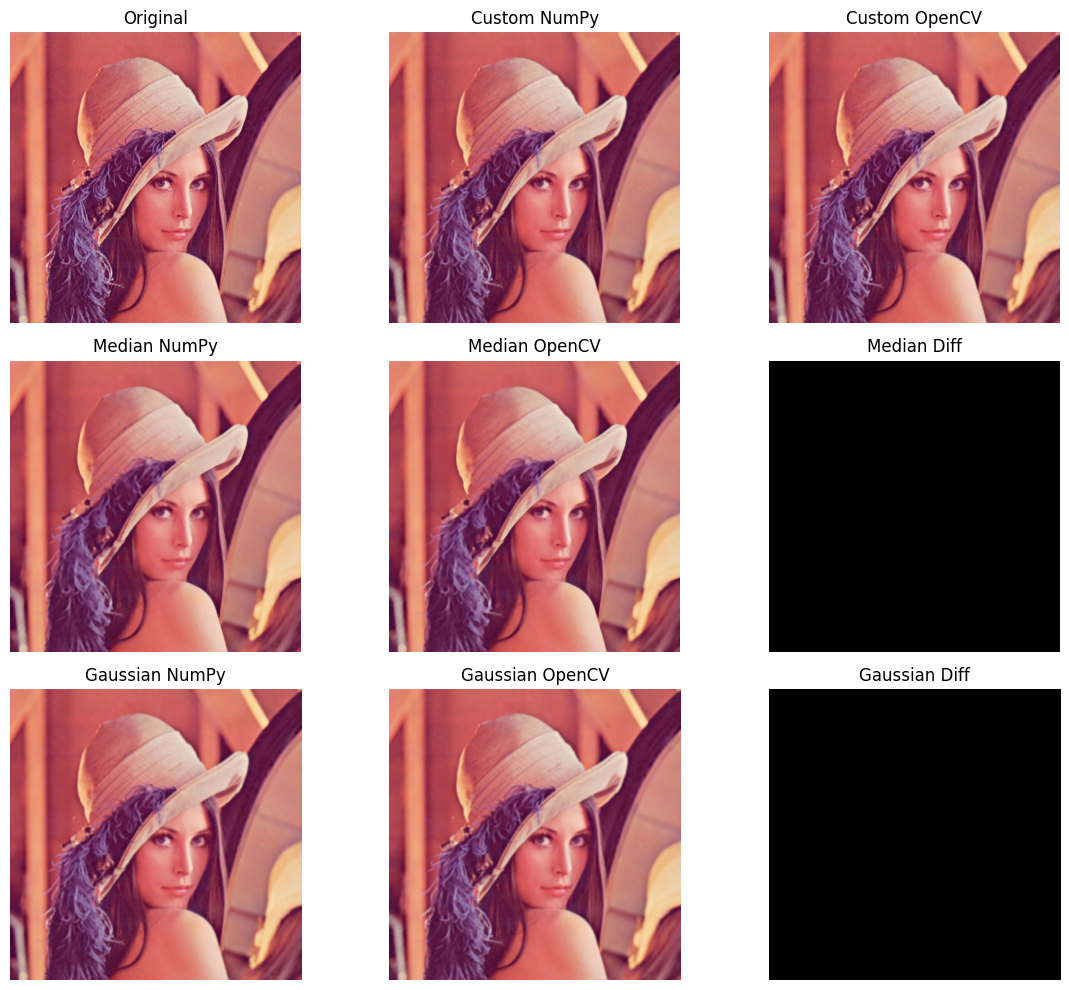

In [9]:
custom_numpy = apply_filter_numpy(img, custom_kernel)
median_numpy = median_blur_numpy(img, 5)
gaussian_numpy = gaussian_blur_numpy(img, 5, 1.2)

img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
custom_cv = cv2.filter2D(img_bgr, -1, custom_kernel)
median_cv = cv2.medianBlur(img_bgr, 5)
gaussian_cv = cv2.GaussianBlur(img_bgr, (5, 5), 1.2)

custom_cv = cv2.cvtColor(custom_cv, cv2.COLOR_BGR2RGB)
median_cv = cv2.cvtColor(median_cv, cv2.COLOR_BGR2RGB)
gaussian_cv = cv2.cvtColor(gaussian_cv, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 10))

plt.subplot(3, 3, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(3, 3, 2)
plt.imshow(custom_numpy)
plt.title("Custom NumPy")
plt.axis("off")

plt.subplot(3, 3, 3)
plt.imshow(custom_cv)
plt.title("Custom OpenCV")
plt.axis("off")

plt.subplot(3, 3, 4)
plt.imshow(median_numpy)
plt.title("Median NumPy")
plt.axis("off")

plt.subplot(3, 3, 5)
plt.imshow(median_cv)
plt.title("Median OpenCV")
plt.axis("off")

plt.subplot(3, 3, 6)
plt.imshow(np.abs(median_numpy.astype(np.int16) - median_cv.astype(np.int16)).astype(np.uint8))
plt.title("Median Diff")
plt.axis("off")

plt.subplot(3, 3, 7)
plt.imshow(gaussian_numpy)
plt.title("Gaussian NumPy")
plt.axis("off")

plt.subplot(3, 3, 8)
plt.imshow(gaussian_cv)
plt.title("Gaussian OpenCV")
plt.axis("off")

plt.subplot(3, 3, 9)
plt.imshow(np.abs(gaussian_numpy.astype(np.int16) - gaussian_cv.astype(np.int16)).astype(np.uint8))
plt.title("Gaussian Diff")
plt.axis("off")

plt.tight_layout()
plt.show()